In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("D:/Deep Learning/Anomaly Detection/data/predictive_maintenance.csv")

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [34]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [35]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [37]:
normal = df[df["Machine failure"] == 0]
failure = df[df["Machine failure"] == 1]

In [38]:
print(normal["Torque [Nm]"].mean())
print(failure["Torque [Nm]"].mean())

39.62965531518476
50.16814159292036


In [10]:
df["UDI"].is_unique

True

In [11]:
df['Product ID'].is_unique

True

In [12]:
df['Product ID'].unique()

<ArrowStringArray>
['M14860', 'L47181', 'L47182', 'L47183', 'L47184', 'M14865', 'L47186',
 'L47187', 'M14868', 'M14869',
 ...
 'L57170', 'M24851', 'L57172', 'L57173', 'L57174', 'M24855', 'H39410',
 'M24857', 'H39412', 'M24859']
Length: 10000, dtype: str

In [13]:
df['Type'].unique()

<ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [14]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [15]:
df['Air temperature [K]'].describe()

count    10000.000000
mean       300.004930
std          2.000259
min        295.300000
25%        298.300000
50%        300.100000
75%        301.500000
max        304.500000
Name: Air temperature [K], dtype: float64

In [41]:
normal = df[df['Air temperature [K]'] == 0]
failure = df[df['Air temperature [K]'] == 1]

In [42]:
print(normal["Air temperature [K]"].mean())
print(failure["Air temperature [K]"].mean())

nan
nan


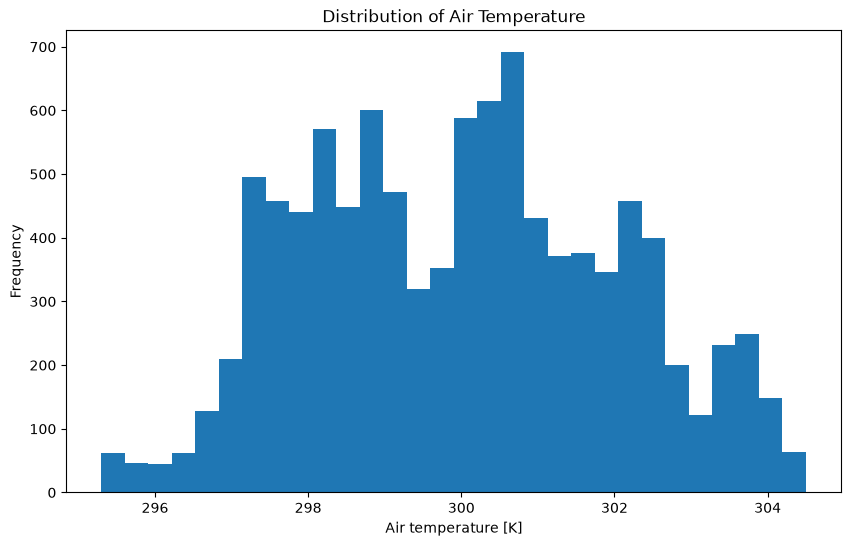

In [16]:
#Histogram (spread)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Air temperature [K]'], bins=30)
plt.xlabel('Air temperature [K]')
plt.ylabel('Frequency')
plt.title('Distribution of Air Temperature')
plt.show()

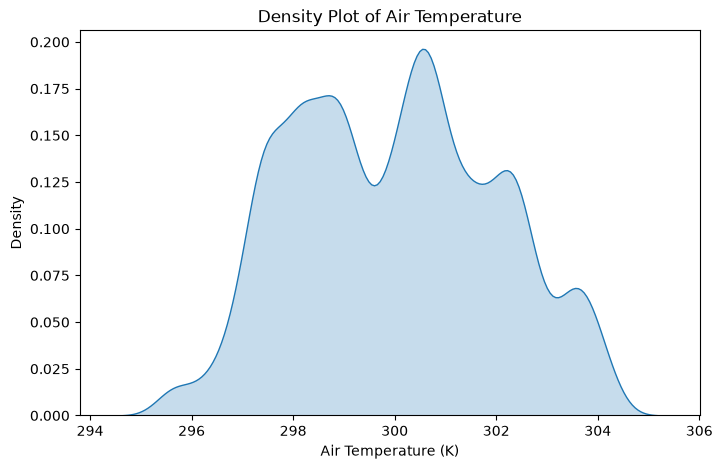

In [17]:
#KDE Plot (Smooth distribution)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['Air temperature [K]'], fill=True)
plt.xlabel('Air Temperature (K)')
plt.title('Density Plot of Air Temperature')
plt.show()

In [18]:
df['Process temperature [K]'].describe()

count    10000.000000
mean       310.005560
std          1.483734
min        305.700000
25%        308.800000
50%        310.100000
75%        311.100000
max        313.800000
Name: Process temperature [K], dtype: float64

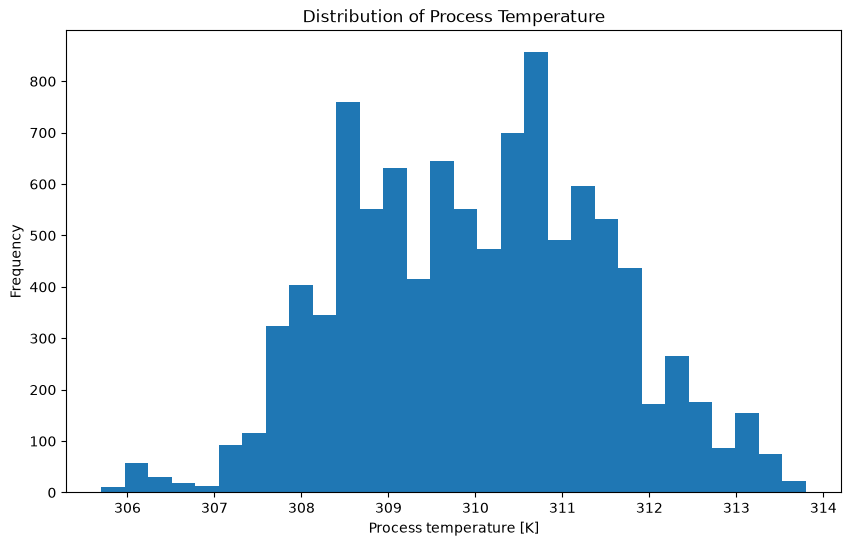

In [19]:
#Histogram (spread)
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Process temperature [K]'], bins=30)
plt.xlabel('Process temperature [K]')
plt.ylabel('Frequency')
plt.title('Distribution of Process Temperature')
plt.show()

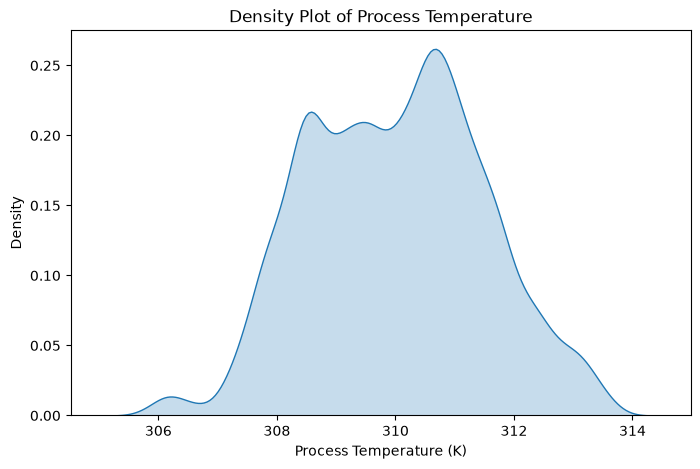

In [20]:
#KDE Plot (Smooth distribution)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['Process temperature [K]'], fill=True)
plt.xlabel('Process Temperature (K)')
plt.title('Density Plot of Process Temperature')
plt.show()

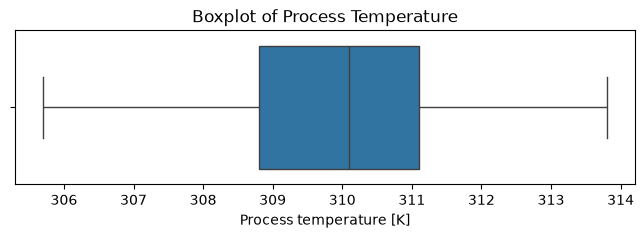

In [21]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Process temperature [K]'])
plt.title('Boxplot of Process Temperature')
plt.show()

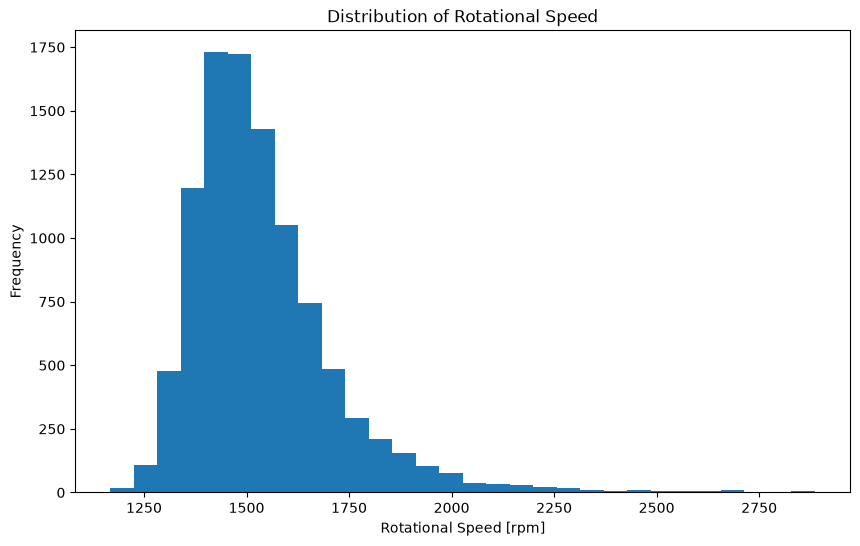

In [22]:
df['Rotational speed [rpm]']

#Histogram (spread)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Rotational speed [rpm]'], bins=30)
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Frequency')
plt.title('Distribution of Rotational Speed')
plt.show()

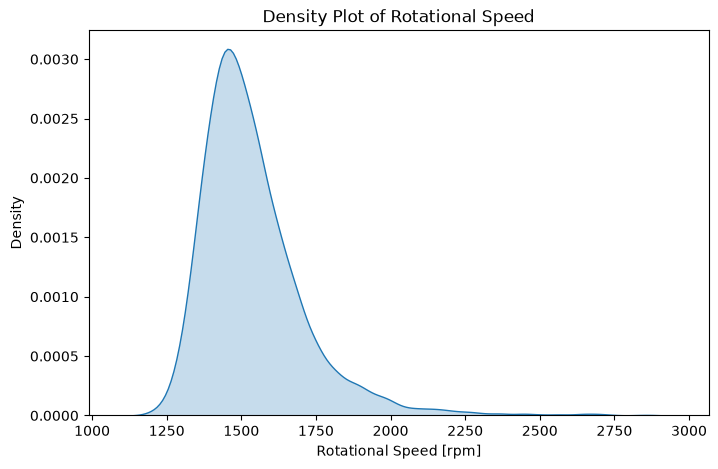

In [23]:
#KDE Plot (Smooth distribution)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['Rotational speed [rpm]'], fill=True)
plt.xlabel('Rotational Speed [rpm]')
plt.title('Density Plot of Rotational Speed')
plt.show()

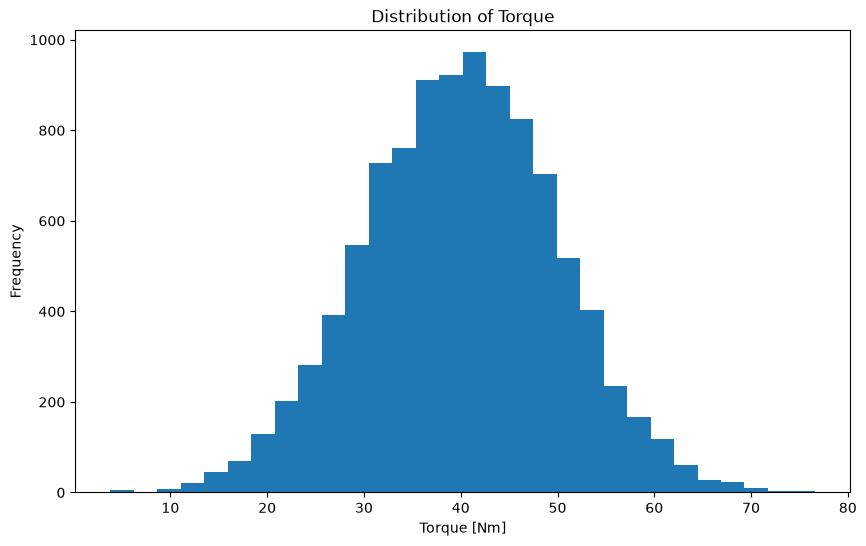

In [24]:
#Histogram (spread)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Torque [Nm]'], bins=30)
plt.xlabel('Torque [Nm]')
plt.ylabel('Frequency')
plt.title('Distribution of Torque')
plt.show()

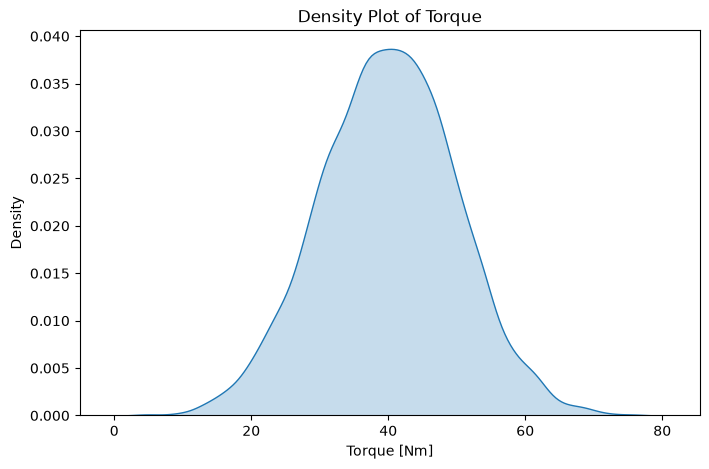

In [25]:
'Torque [Nm]'
#KDE Plot (Smooth distribution)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['Torque [Nm]'], fill=True)
plt.xlabel('Torque [Nm]')
plt.title('Density Plot of Torque')
plt.show()

In [36]:
df['Tool wear [min]'].value_counts()

Tool wear [min]
0      120
2       69
5       63
7       58
59      58
      ... 
237      1
239      1
241      1
251      1
253      1
Name: count, Length: 246, dtype: int64

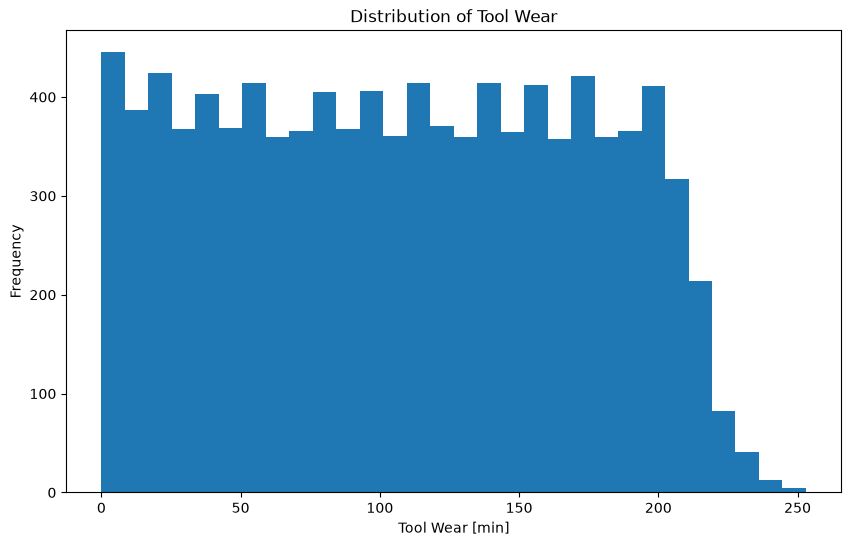

In [27]:
#Histogram (spread)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Tool wear [min]'], bins=30)
plt.xlabel('Tool Wear [min]')
plt.ylabel('Frequency')
plt.title('Distribution of Tool Wear')
plt.show()

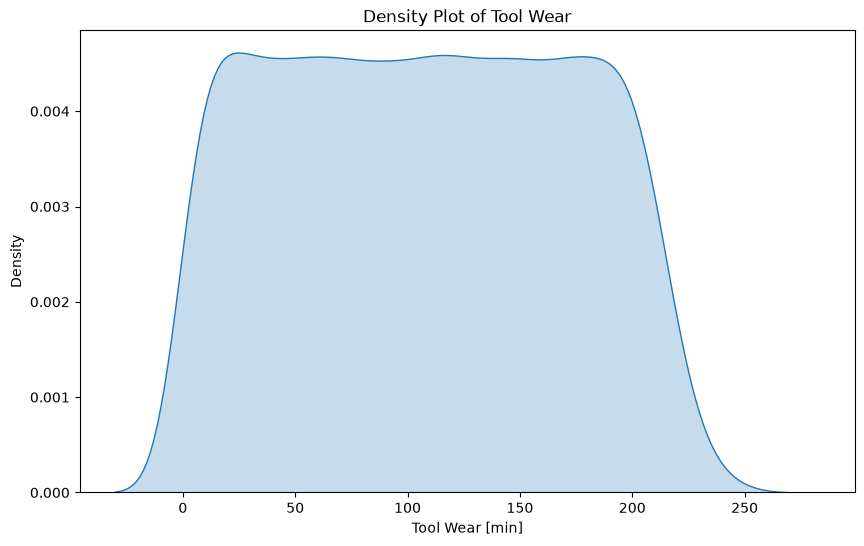

In [28]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(df['Tool wear [min]'], fill=True)
plt.xlabel('Tool Wear [min]')
plt.title('Density Plot of Tool Wear')
plt.show()

In [30]:
df['TWF'].value_counts()

TWF
0    9954
1      46
Name: count, dtype: int64